<H1> First project: charged particle trapped in a magnetic field </H1>

**By:** Santiago Andrés Acosta Díaz

**For:** Computational Astrophysics

### Some Markdown/LaTeX commands
In this block, I'm writing some commands to ease the LaTeX writing process.

_Ignore this cell_


$$
\newcommand{\pdv}[2]{\frac{\partial #1}{\partial #2}}
\newcommand{\vdot}[1]{{\dot{\vec #1}}}
\newcommand{\vddot}[1]{{\ddot{\vec #1}}}
$$

### Python library imports


In [1]:

import numpy as np
from numba import jit
import matplotlib.pyplot as plt

# Phase 1

<H3> Mathematical framing of Particle Dynamics </H3>

## Derivation of the equations of motion

In this section, we'll analytically derive the motion equations for the Cartesian coordinates of a charged particle under the influence of a dipole magnetic field, given the Lorentz Force equation

$$
F_{L} = q \left( \vec E + \vec v \times \vec B \right)
$$


### Solution

For this, we first have to state that 

* Electric field $\vec E = 0$
* The magnetic field is a dipole with shape (given from eq (6) from the study material) $\vec B_{dip} = -\frac{B_0 R_e^3}{r^5} \left[ 3xz \hat x + 3yz \hat y + (2z^2 - x^2 - y^2)\hat z \right]$

Now, with that, we have the equation to solve as follows

$$ 
\begin{align}
\vddot{r} &= \frac{q}{m} \dot {\vec r} \times \vec B_{dip} \\
\vddot{r} &= \underbrace{-\frac{q B_0 R_e^3}{m}}_{\Omega} \frac{1}{r^5}\, \dot {\vec r}  \times (3xz, 3yz, 3z^2 - r^2)
\end{align}
$$

considering that $r^2 = x^2 + y^2 + z^2$ and we define $\Omega = -\frac{q B_0 R_e^3}{m}$ to ease the notation, as it is a global constant.

Now, as numerically we have to treat each coordinate separately, we'll have to find the vector expression of the cross product

$$
\begin{align}
    \vdot r \times (3xz, 3yz, 3z^2 - r^2) & = 
    \left|
    \begin{matrix}
        \hat x & \hat y & \hat z \\ 
        \dot x & \dot y & \dot z \\ 
        3xz & 3yz & 3z^2 - r^2
    \end{matrix} 
    \right| \\
    &= \left( \dot y (3z^2 - r^2) - \dot z (3yz),\, \dot z(3xz) - \dot x(3z^2 - r^2),\, \dot x (3yz) - \dot y (3xz) \right)
\end{align}
$$

from where we can get the equations of motion for each coordinate



### Answer

$$
\boxed{
\begin{gather}
    \ddot x  = \frac{\Omega}{r^5} \left[ (3 z^2 - r^2) \dot y - 3yz \dot z \right] \\
    \ddot y  = \frac{\Omega}{r^5} \left[ 3xz \dot z - (3 z^2 - r^2) \dot x \right] \\
    \ddot z  = \frac{\Omega}{r^5} \left[ 3z \left( y \dot x  - x \dot y \right) \right]
\end{gather}}
$$

## Numerical differentiation specification

Implement finite difference approximations derived from Lagrange interpolation.

In this section, we're asked to implement finite differences derivation algorithms from Lagrange interpolation according to "A General Formula for the Numerical Differentiation of a Function" by A. K. SINGH AND G. R. THORPE. What matters here is that these formulas are the same ones we get from the Taylor expansions done previously during class, as one can see on equations (3.2) and (3.3) of the paper. 

With that in mind, the task is no other than implement these algorithms: 


For **first derivative with $n=2$:**

* Forwards difference: $$ f'(x) \approx \frac{4f(x + h) - f(x + 2h) - 3f(x)}{2h}$$
* Backwards difference: $$ f'(x) \approx \frac{3f(x) + f(x - 2h) - 4f(x - h)}{2h}$$
* centered difference: $$ f'(x) \approx \frac{f(x + h) - f(x-h)}{2h}$$


For **first derivative with $n=3$:** the same as we have on the table in the study material for $s = 4$



For **second derivative with $n=2$:**

* Forwards difference: $$ f''(x) \approx \frac{f(x - h) - 2f(x) + f(x+h)}{h^2}$$

In [2]:
'''
In order to make the calculations of the first derivative efficient and only needing one function, 
we'll create a look-up table that contains all the coefficients for the f_i f_{\pm i} and f_{\pm 2i} algorithms

STRUCTURE: dict
keys: tuple (nodal points n, type of algorithm)
(n = [2, 3], type of algorithm = ["f(orward)", "b(ackward)", "c(entral)"]) 

items: tuple
( (array with the coefficients), (array with the offests) )
'''

FD_COEFFS = {
    (2, "f"): (np.array([-3/2, 2, -1/2]), np.array([0, 1, 2])),
    (2, "b"): (np.array([3/2, -2, 1/2]), np.array([0, -1, -2])),
    (2, "c"): (np.array([-1/2, 0, 1/2]), np.array([-1, 0, 1])),
    
    (3, "f"): (np.array([-11, 18, -9, 2]) / 6.0, np.array([0, 1, 2, 3])),
    (3, "b"): (np.array([-2, 9, -18, 11]) / 6.0, np.array([-3, -2, -1, 0])),
    (3, "c1"): (np.array([-2, -3, 6, -1]) / 6.0, np.array([-1, 0, 1, 2])),
    (3, "c2"): (np.array([1, -6, 3, 2]) / 6.0, np.array([-2, 1, 0, 1]))
}


def fo_derivative(f, x, h=1e-5, n=3, t="c"):
    """ This function represents the first order derivative approximation.
    It basically performs the algorithms seen above but, in order to have them all in one
    only function and still be efficient, we use a lookup table with the coefficients and the offsets """

    # We get the coefficients and offsets array
    coeffs, offsets = FD_COEFFS[(n, t)]
    
    # Create shifted evaluation points  
    shifted = x[np.newaxis, :] + offsets[:, np.newaxis] * h
    values = f(shifted)   
    
    return (coeffs[:, None] * values).sum(axis=0) / h

def so_derivative(f, x, h=1e-5):
    """ Now, for the second order derivative, which we need a single algorithm """

    return (f(x - h) - 2.0 * f(x) + f(x + h)) / (h**2)

# Phase 2

<H3>Algoritmic generalization and lagrange interpolation</H3>

The first todo thing is to implement the Lagrange interpolation seen on class, which mathematically can be expressed as

$$
f(x) = \sum_{j = 0}^{n} l_j (x) f(x_j); \qquad \text{where} \quad l_j(x) = \prod_{i \ne j}^n \frac{x-x_i}{x_j - x_i}
$$

_[note that I'm not using the same expression as the one given in class, as this one is easier to interpret and code]_

where $n$ is the ammount of _nodal points_, and $x_j$ is the position of the $j$-th nodal point. What actually matters in this expression is that, when $x = x_j$ for any $j$, $l_j(x=x_j) = 1$ while $0$ for any other nodal point. 

### How to use this in the project

At the end, what we'll do is to create a grid on the 3D space of a vector function. To that end, we need to first generalize this idea to more than 1 dimension and more than 1 output, and second, make it efficient. 

The first item is easy to achieve, given that 

$$
\vec B(\vec r) = \vec B(x, y, z) = (B_x(x, y, z), B_y(x, y, z), B_z(x, y, z))
$$

we can then interpolate every component of the resulting magnetic field, and furthermore, we can generalize this for our 3D input space simply as

$$
\vec B(\vec r) = \sum_{j_x = 0}^{n} \sum_{j_y = 0}^{n} \sum_{j_z = 0}^{n} l_{j_x}{x} l_{j_y}{y} l_{j_z}{z} (x) f(\vec r_j);
$$

## Why to avoid it in this simulation

One can think of the magnetic field as a mathematical entity (sorry if it sounds too mystical) whose properties are highly sensitive. That is, from Maxwell's equations, in this specific scenario, without $\vec E$, we have 

$$
    \nabla \cdot \vec B = 0 \\ 
$$

Which basically accounts for the non-monopolar behavior of $\vec B$. 

The prior equation is highly sensitive to the shape of $\vec B$, so if we approximate our field to be of a polynomial shape, we should ensure that the approximation satisfies this property of magnetic fields to be physically correct; something that Lagrange interpolation will not really care about. 

With this said, basically, we expect that using Lagrange interpolation to approximate the magnetic field just gives terrible results as it will not ensure the null divergence propoerty of it. A workaround that may help with this is simply finding a vector potential $\vec A$ that recreates $\vec B$ and interpolating it, to then reconstruct $\vec B$ by using the interpolation of $\vec A$, which would be more physically correct. 

## Numerical implementation

Here, we'll implement the Lagrange interpolator function considering all that was previously discussed. Inside of the code's comments a brief explanation of what we're doing is shown.

In [3]:
def lagrange_basis(x, nodes, j):
    """ Compute the j-th Lagrange basis polynomial at point x """
    
    result = 1.0     # Here we'll save the result of the l_j calculation
    
    for i in range(len(nodes)):
        # Simply perform such calculation as explained above
        if i != j:
            result *= (x - nodes[i]) / (nodes[j] - nodes[i])
            
    return result


def interpolate_vector_field(x, grid, field):
    """
    3D Lagrange interpolation of a vector field.
    """
    
    x_q, y_q, z_q = x   # The actual point to evaluate
    
    x_n, y_n, z_n = grid    # The grid we have
    
    nx, ny, nz = len(x_n), len(y_n), len(z_n)    # The size of the grid on each dimention


    # Here, we create the Lagrange basis for each dimention
    lx = np.array([lagrange_basis(x_q, x_n, i) for i in range(nx)])
    ly = np.array([lagrange_basis(y_q, y_n, j) for j in range(ny)])
    lz = np.array([lagrange_basis(z_q, z_n, k) for k in range(nz)])


    # Here we do the tensor product of all we just calculated to get the final result
    return np.einsum('i, j, k, ijkc -> c', lx, ly, lz, field)



def interpolate_from_function(x, grid, func):
    """
    Same as above but takes a function instead of pre-computed field values.
    """
    
    x_n, y_n, z_n = grid    # We decompose the grid
    
    X, Y, Z = np.meshgrid(x_n, y_n, z_n, indexing='ij') # Create the meshgrid
    
    Bx, By, Bz = func(X, Y, Z)   # Get the magnetic field
    field = np.stack([Bx, By, Bz], axis=-1)   # Do this because the shape was weird 
    
    return interpolate_vector_field(query, grid, field)

## Checking validity of the Lagrange Interpolation

In this section, we'll see how the Lagrange interpolation works and how valid it is when using it with Earth's dipole field. 

In [4]:
# Define Earth's dipole field
def earth_dipole_field(pos):

    x, y, z = pos
    
    # Calculate radial distance r
    r = np.sqrt(x**2 + y**2 + z**2)
    
    # if we're on the center of Earth (which should not happen a priori), just make it 0
    if r < 1e-10:
        return np.array([0.0, 0.0, 0.0])
        
    # The combined constant
    C = 10.668
    
    # The prefactor
    prefactor = -C / (r**5)
    
    # Calculate the B field components
    Bx = prefactor * (3 * x * z)
    By = prefactor * (3 * y * z)
    Bz = prefactor * (2 * z**2 - x**2 - y**2)
    
    return np.array([Bx, By, Bz])

Here, we'll prepare everything to show the demonstration on how the interpolator works here. I'll ask GeminAI to help be doing these plots

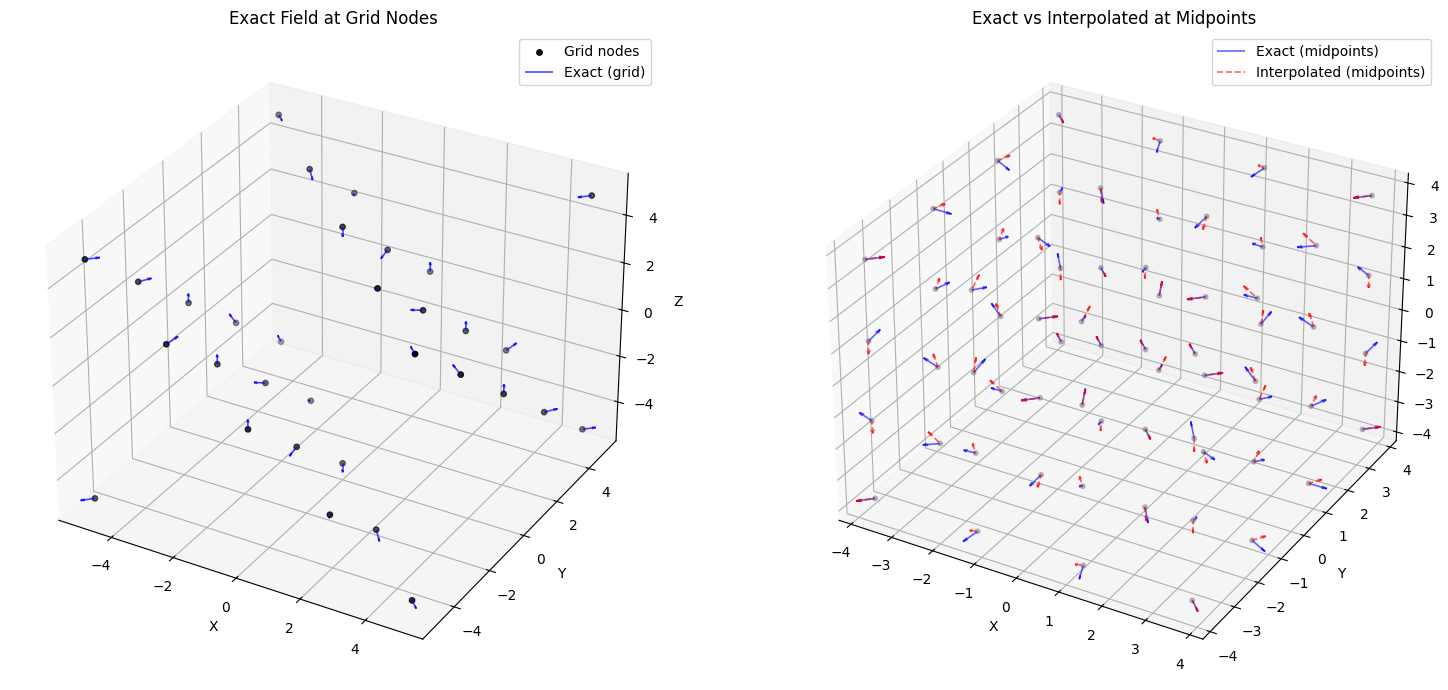

In [5]:
# --- Build the grid ---
n = 5
lim = 5.0
x_nodes = np.linspace(-lim, lim, n)
y_nodes = np.linspace(-lim, lim, n)
z_nodes = np.linspace(-lim, lim, n)
grid = (x_nodes, y_nodes, z_nodes)

nx, ny, nz = len(x_nodes), len(y_nodes), len(z_nodes)
field = np.zeros((nx, ny, nz, 3))
for i in range(nx):
    for j in range(ny):
        for k in range(nz):
            field[i, j, k] = earth_dipole_field((x_nodes[i], y_nodes[j], z_nodes[k]))

# --- Midpoints ---
x_mid = 0.5 * (x_nodes[:-1] + x_nodes[1:])
y_mid = 0.5 * (y_nodes[:-1] + y_nodes[1:])
z_mid = 0.5 * (z_nodes[:-1] + z_nodes[1:])

# --- Collect exact and interpolated at midpoints ---
mid_pos = []
B_exact_list = []
B_interp_list = []

for x in x_mid:
    for y in y_mid:
        for z in z_mid:
            mid_pos.append([x, y, z])
            B_exact_list.append(earth_dipole_field((x, y, z)))
            B_interp_list.append(interpolate_vector_field((x, y, z), grid, field))

mid_pos = np.array(mid_pos)
B_exact_arr = np.array(B_exact_list)
B_interp_arr = np.array(B_interp_list)

# --- Also collect exact field at grid nodes for plotting ---
grid_pos = []
B_grid_list = []
for i in range(nx):
    for j in range(ny):
        for k in range(nz):
            grid_pos.append([x_nodes[i], y_nodes[j], z_nodes[k]])
            B_grid_list.append(field[i, j, k])

grid_pos = np.array(grid_pos)
B_grid_arr = np.array(B_grid_list)

# --- Subsample for clarity (too many arrows = unreadable) ---
stride_grid = 4
stride_mid = 1

grid_idx = np.arange(0, len(grid_pos), stride_grid)
mid_idx = np.arange(0, len(mid_pos), stride_mid)

# --- Normalize arrows for visibility ---
def normalize_arrows(B, scale=0.4):
    norms = np.linalg.norm(B, axis=1, keepdims=True)
    norms[norms < 1e-15] = 1.0
    return scale * B / norms

B_grid_norm = normalize_arrows(B_grid_arr[grid_idx])
B_exact_norm = normalize_arrows(B_exact_arr[mid_idx])
B_interp_norm = normalize_arrows(B_interp_arr[mid_idx])

# --- Plot ---
fig = plt.figure(figsize=(16, 7))

# Left: Grid nodes + exact field
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(*grid_pos[grid_idx].T, c='black', s=15, label='Grid nodes')
ax1.quiver(
    *grid_pos[grid_idx].T, *B_grid_norm.T,
    color='blue', alpha=0.7, linewidth=1.2, label='Exact (grid)'
)
ax1.set_title('Exact Field at Grid Nodes')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.legend()

# Right: Midpoints — exact vs interpolated
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(*mid_pos[mid_idx].T, c='gray', s=10, alpha=0.5)
ax2.quiver(
    *mid_pos[mid_idx].T, *B_exact_norm.T,
    color='blue', alpha=0.6, linewidth=1.2, label='Exact (midpoints)'
)
ax2.quiver(
    *mid_pos[mid_idx].T, *B_interp_norm.T,
    color='red', alpha=0.6, linewidth=1.2, linestyle='dashed', label='Interpolated (midpoints)'
)
ax2.set_title('Exact vs Interpolated at Midpoints')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.legend()

plt.tight_layout()
plt.show()

## What are we seeing?

The above graphs show us something really important. In order to explain it, we need to understand that the interpoltion we do between two known points is not by any means the real function we're dealing with, but just a sort of "function that, in the case of being being used, could reproduce our original points". With that in mind, and if we check the shape of our original field, which is not of polynomial shape, we cannot expect the interpolation to be perfect.

This can be seen on the right graph, where it is clear that the interpolated field is not close to replicate the original field. 

This will not only mess the numerical simulation (which is expected as we're "approximating" the field), but, as explained above, will lead to unphysical results just for the fact of been working with unphysical magnetic fields.

So, with this done, I've decided to work with the original exact fields, as, for this simulation, calculating it is not expensive and thus there's not a real need to interpolate it.

# Phase 3
<H3>Unit Handling and Physical Parameters</H3>


For this section, we're asked to "normalize" our system, given that

* *Initial radius:* $8 R_e$
* *Magnetic Field Constant:* $B_0 = 2.667$
* *Charge to mass ratio:* $q/m = 4$
* *Initial Kinetic Energy:* $K_0 = 7$

With these items in mind, we can see that _2_ and _3_ are directly satisfied by tuning the $\Omega$ parameter on the equations of motion we derived earlier, 

$$
    \Omega = -\frac{q}{m} R_e^3 B_0 = 4 \cdot (1)^3 \cdot 2.667 \approx 10.668
$$

and in order to ensure _1_, we can make $R_e = 1$ so what we have to ensure is that the initial conditions of the solver satisfy:

$$
    |r_0| = \sqrt{x_0^2 + y_0^2 + z_0^2} = 8
$$

and 

$$
    |v_0| = \sqrt{\dot x_0^2 + \dot y_0^2 + \dot z_0^2} = \sqrt{\frac{2}{m} K_0} = \sqrt{\frac{14}{m}} 
$$

and thus satisfiying contiditions _1_ and _4_. The value of $m$ we'll use will depend on the exact exercise.


**Note:_so far we do not code any of these yet as each exercise changes these parameters_**

# Phase 4

<H3>Numerical Integration and Methodological comparison</H3>

Here, we're asked to implement a numerical integrator. In this case, I will use a symplictic integrator that was specifically made for this type of problems, the *Boris Method*

What this does is to, given the position at times $n - \frac{1}{2}$ and $n + \frac{1}{2}$, we calculate the rotation produced by the magnetic field by using the _average velocity_ on these two points. This method also defines two _auxiliar_ velocities $v^+$ and $v^-$ such that the final ODE to solve does not depend on the electric field, but as our examples have $E=0$, these auxiliar velocities are simply $v^- = v^{n-1/2}, \,\, v^+ = v^{n + 1/2}$; and with the help of an auxiliar _rotation vector_ $\vec t =\frac{q \vec B}{m} \frac{\Delta t}{2}$, we can define the step as

$$
    \vec v^+ = \vec v^- + \left( \vec v^- + \vec v^- \times \vec t \right) \times \vec s
$$

where $\vec s = \frac{2 \vec t}{1 + t^2}$.

_Note: this was taken from https://www.particleincell.com/2011/vxb-rotation/_


From this evaluation of $\vec v$, we can then "Runge-Kute 2" integrate the old position. That is, given the $v^-$ and $v^+$, we can integrate the new position $x^+$ as

$$
    x^+ = x^- + \frac{v^- + v^+}{2} \Delta t
$$

This method is a symplictic method derived specifically for electromagnetic field problems.

In [6]:
def boris_integrator(pos, vel, B, q, m, dt):
    """
        Boris integrator as explained above. That is, it takes no electric field
    """
    
    # Calculate \vec t
    t = (q / m) * B * (dt / 2.0)
    
    # Calculate \vec s
    s = 2.0 * t / (1.0 + np.dot(t, t))
    
    # Perform the velocity rotation
    v_minus = vel
    
    v_prime = v_minus + np.cross(v_minus, t)  # \vec v' is what's inside the parentheses on the v+ expression
    v_plus = v_minus + np.cross(v_prime, s)
    
    # Update the position
    new_pos = pos + v_plus * dt
    
    return new_pos, v_plus


After this, we're asked to show a comparative explanation on how the truncation errors on the derivatives behave. In this case, _Boris Method_ was fabricated using **centered finite differences derivatives**, as seen in the expression (citing the web page above)

$$
    \frac{x^{n+1/2} - x^{n - 1/2}}{\Delta t} = v^{n + 1/2}.
$$

With that in mind, the truncation error is that from taking $s = 1$, and thus, it is

$$
    E_{c} = -\frac{h^2}{6} f^{(3)}(\zeta)
$$

which in general performs better than $s = 0, 2$, as this error will always be

$$
    E_{b} = E_{f} = -2 E_{c}
$$,

In general, our error using this method will be at least half as large as that produced by the method using backward or forward differences.

# Phase 5

<H3>Physical Validation and Adiabatic Invariants</H3>

In this section, we're asked basically for 3 things:

1. Calculate the _magnetic moment_ $\mu = \frac{E_\perp}{B} = \frac{1}{2B} m v^2_\perp $ (there could be a $\gamma$ factor) and check it's conservation
2. Check conservation of total energy $E = E_\parallel + E_\perp$
3. Check for mirror points using the bisection method.

## Magnetic moment

The magnetic moment is that one defined above, but for it to be conserved, something very imporant has to happen. 

As said in the study material: _When system parameters **vary slowly relative to oscillation frequencies**, the system possesses an adiabatic invariant._, which in this case, is $\mu$. The important fact here is that this will only happen if that condition of _slow variation with respect to oscillation_ is satisfied. 

To elaborate further, let's think about the movement of a particle on a magnetic field: it will always tend to spiral around the magnetic field line. Considering this, what we need to be satisfied so the magnetic moment is conserved is that the magnetic field on the region the particle spiral around varies slowly. We have two main mechanism to achieve this

1. Simply force the field to vary slowly
2. Make the particle spiral very close to it's guiding center so the changes in the field are small.

Option 1 is simply not physical: we cannot change the Earth's magnetic field to be uniform. By the other hand, it is possible to change the radius of oscillation of the particle by simply tweaking the initial conditions, as this radius $r_L$ (Lamour's radius) has a very well known formula.

$$
r_L = \frac{m v_\perp}{qB}
$$

so by tweaking the initial velocity $\vec v_0$ we can force smaller $r_L$ and satisfy the adiabatic conditions.

## Deal with components

For all 3 items above, we have to be able to get all the components of the velocity (given that $E = E(v)$). 

If we wanted to simply check energy conservation, we could simply calculate $E$ given the velocity in the Cartesian coordinates, but for $\mu$ and checking mirror points, we do in fact need the velocity components with respect to the local magnetic field $\vec B(\vec r)$. To get these, considering that both expressions of our velocity and magnetic field are in Cartesian coordinates, we can get them as

$$
    \vec v_\parallel = \frac{\vec v \cdot \vec B}{B}
$$

and with these value, calculate the perpendicular velocity as

$$
    \vec v_{\perp} = \vec v - \vec v_{\parallel}
$$

from which we can, from $v_\parallel$, get an approximation of the mirror point as the root of this magnitude, which will be calculated as

$$
    \lambda_m =  \lambda \text{ where } v_\parallel = 0 
$$

and will be the midpoint between the $\lambda$s where $v_\parallel(\lambda_-) \cdot v_\parallel(\lambda_+) < 0$. That is, we'll use the bisection method.

In [7]:
def get_parallel_velocity(v, B):
    ''' We simply return the dot product between the velocity and the unitary magnetic field
    on the local point and account for possible singulatiries'''
    
    B_mag = np.linalg.norm(B)
    if B_mag < 1e-14:
        return 0.0
    return np.dot(v, B / B_mag)

def get_perpendicular_velocity(v, v_par):
    ''' We just get the perp component from the complement of the vel and the parlallel component '''
    return max(0.0, np.sqrt(np.dot(v, v) - v_par**2))
    # return max(0.0, (np.linalg.norm(v) - v_par))

def get_energy(v, m):
    ''' Kinetic energy '''
    return 0.5 * m * v**2

def get_mu(E_perp, B_mag):
    ''' Magnetic moment and account for singularities '''
    return E_perp / B_mag if B_mag > 1e-14 else 0.0

# Simulations

## Setting up the simulation

We'll first create a class that will save every simulation. That is, the particle's properties, the simulation initial conditions and parameters. And that has methods to run the simulation

In [92]:
class SimulationSetup:
    def __init__(self, charge, mass, initial_pos, initial_vel, b_field, dt, num_steps, _keep_mu = 0.2, plot_lim = 0.0):
        self.q = charge
        self.m = mass
        self.pos = np.array(initial_pos, dtype=float)
        self.vel = np.array(initial_vel, dtype=float)
        self.dt = dt
        self.num_steps = num_steps
        self.keep_mu = _keep_mu
        self.plot_lim = plot_lim
        # As the magnetic field can be constant or a function, we have to check first
        # which type of thing we have
        if callable(b_field):
            # If B is a function, we simply call the function
            self.get_b_field = b_field
        else:
            # Else, we make a function that always returns the same field
            b_const = np.array(b_field, dtype=float)
            self.get_b_field = lambda position: b_const

        # Where we'll save up everything
        self.history_time = np.zeros(num_steps)
        self.history_pos = np.zeros((num_steps, 3))
        self.history_vel = np.zeros((num_steps, 3))
        
        self.history_v_parallel = np.zeros(num_steps)
        self.history_E_parallel = np.zeros(num_steps)
        self.history_E_perp = np.zeros(num_steps)
        self.history_E_total = np.zeros(num_steps)
        self.history_mu = np.zeros(num_steps)
        
        self.history_pos[0] = self.pos
        self.history_vel[0] = self.vel
        self.mirror_points = []

    def _compute_diagnostics(self, index, pos, vel):
        """We'll compute all the physical diagnostics to check if we're doing it right"""
        B_local = self.get_b_field(pos)    # Call the magnetic field
        B_mag = np.linalg.norm(B_local)    # Get it's magnitude for later calculations
        
        # Get the velocities
        v_par = get_parallel_velocity(vel, B_local)
        v_perp = get_perpendicular_velocity(vel, v_par)
        
        # Get the energies
        E_par = get_energy(v_par, self.m)
        E_perp = get_energy(v_perp, self.m)
        # E_total = get_energy(np.linalg.norm(vel), self.m)
        E_total = E_par + E_perp
        
        # Get the magnetic moment
        mu = get_mu(E_perp, B_mag)
        
        # Store data
        self.history_v_parallel[index] = v_par
        self.history_E_parallel[index] = E_par
        self.history_E_perp[index] = E_perp
        self.history_E_total[index] = E_total
        self.history_mu[index] = mu
        
        return v_par

    def run(self, integrator = boris_integrator):
        """ Here we run the whole simulation """
        
        print("Starting simulation...")
        
        prev_v_parallel = self._compute_diagnostics(0, self.pos, self.vel)
        
        for i in range(1, self.num_steps):
            # Get the magnetic field
            B_local = self.get_b_field(self.pos)
            
            # We integrate using the integrator (default is Boris one)
            self.pos, self.vel = integrator(
                self.pos, self.vel, B_local, self.q, self.m, self.dt
            )

            # Update the historic kinetics
            self.history_pos[i] = self.pos
            self.history_vel[i] = self.vel
            self.history_time[i] = i * self.dt
            
            # Diagnostics 
            current_v_parallel = self._compute_diagnostics(i, self.pos, self.vel)
            
            # Mirror point detection
            if current_v_parallel * prev_v_parallel < 0:
                # We check the reflection points using the bisection method (as discussed priorly)
                time = i * self.dt
                self.mirror_points.append({'time': time, 'pos': self.pos.copy()})
                
            prev_v_parallel = current_v_parallel

        print("Simulation complete.")

    def plot_results(self):
        """ Plotting the results (I asked gemini to do this TBH) """
        fig = plt.figure(figsize=(18, 5))
        
        ax1 = fig.add_subplot(131, projection='3d')
        ax1.plot(self.history_pos[:, 0], self.history_pos[:, 1], self.history_pos[:, 2], color='b')
        for mp in self.mirror_points:
            ax1.scatter(*mp['pos'], color='r', s=60, marker='x')

        if self.plot_lim != 0.0:
            ax1.set_ylim(-self.plot_lim, self.plot_lim)
            ax1.set_xlim(-self.plot_lim, self.plot_lim)
            ax1.set_zlim(-self.plot_lim, self.plot_lim)
        
        ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
        ax1.set_title('Particle Trajectory')
        
        ax2 = fig.add_subplot(132)
        ax2.plot(self.history_time, self.history_E_parallel, label=r'$E_{\parallel}$', color='g')
        ax2.plot(self.history_time, self.history_E_perp, label=r'$E_{\perp}$', color='orange')
        ax2.plot(self.history_time, self.history_E_total, label=r'$E_{total}$', color='k', linestyle='--')
        ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Kinetic Energy')
        ax2.set_title('Energy Partition over Time')
        ax2.legend(); ax2.grid(True, alpha=0.3)
        
        ax3 = fig.add_subplot(133)
        ax3.plot(self.history_time, self.history_mu, color='purple')
        mean_mu = np.mean(self.history_mu)
        
        if mean_mu > 0 and self.keep_mu != 0:
            ax3.set_ylim(mean_mu * (1.0 - self.keep_mu), mean_mu * (1.0 + self.keep_mu))
            
        ax3.set_xlabel('Time (s)'); ax3.set_ylabel(r'Magnetic Moment $\mu$')
        ax3.set_title('Conservation of Magnetic Moment')
        ax3.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

    def compute_guiding_center(self):
        self.history_gc_pos = np.zeros((self.num_steps, 3))
        self.history_mu_gc = np.zeros(self.num_steps)
    
        for i in range(self.num_steps):
            pos = self.history_pos[i]
    
            # Synchronize velocity: average consecutive half-steps
            if 0 < i < self.num_steps - 1:
                vel = 0.5 * (self.history_vel[i] + self.history_vel[i - 1])
            else:
                vel = self.history_vel[i]
    
            B = self.get_b_field(pos)
            B_mag = np.linalg.norm(B)
    
            rho = (self.m / (self.q * B_mag**2)) * np.cross(vel, B)
            self.history_gc_pos[i] = pos + rho
    
            B_gc = self.get_b_field(self.history_gc_pos[i])
            B_gc_mag = np.linalg.norm(B_gc)
            b_hat_gc = B_gc / B_gc_mag
    
            v_par = np.dot(vel, b_hat_gc)
            v_perp_sq = np.dot(vel, vel) - v_par**2
    
            self.history_mu_gc[i] = self.m * v_perp_sq / (2.0 * B_gc_mag)
    
    def plot_guiding_center(self):
        """Plot trajectory + guiding center, and mu comparison (geminAI)"""
        if not hasattr(self, 'history_gc_pos'):
            self.compute_guiding_center()
    
        fig = plt.figure(figsize=(18, 5))
    
        # Left: trajectory + guiding center
        ax1 = fig.add_subplot(121, projection='3d')
        ax1.plot(
            self.history_pos[:, 0], self.history_pos[:, 1], self.history_pos[:, 2],
            color='blue', alpha=0.4, linewidth=0.8, label='Particle'
        )
        ax1.plot(
            self.history_gc_pos[:, 0], self.history_gc_pos[:, 1], self.history_gc_pos[:, 2],
            color='red', linewidth=2, label='Guiding Center'
        )
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        ax1.set_zlabel('Z')
        ax1.set_title('Particle Trajectory & Guiding Center')
        ax1.legend()
    
        # Right: mu at particle vs mu at guiding center
        ax2 = fig.add_subplot(122)
        ax2.plot(self.history_time, self.history_mu, color='blue', alpha=0.4, label=r'$\mu$ at particle')
        ax2.plot(self.history_time, self.history_mu_gc, color='red', linewidth=2, label=r'$\mu$ at guiding center')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel(r'$\mu$')
        ax2.set_title('Magnetic Moment Conservation')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
        plt.tight_layout()
        plt.show()

## Uniform magnetic field

We simply have to check the behaviur of a particle moving on a uniform magnetic field $\vec B = B \hat z$ with $B = 1$T

In [9]:
# Set Physical Parameters
q = 1.0
m = 1.0
initial_pos = [0.0, 0.0, 0.0]  # Start at the origin
initial_vel = [0.1, 0.0, 0.05]  # Moving mainly in x, slight drift in z

# Uniform magnetic field in the z direction
uniform_b_field = [0.0, 0.0, 1.0] 

# Simulation parameters
dt = 1.0e-4
num_steps = int(1e5)

Starting simulation...
Simulation complete.


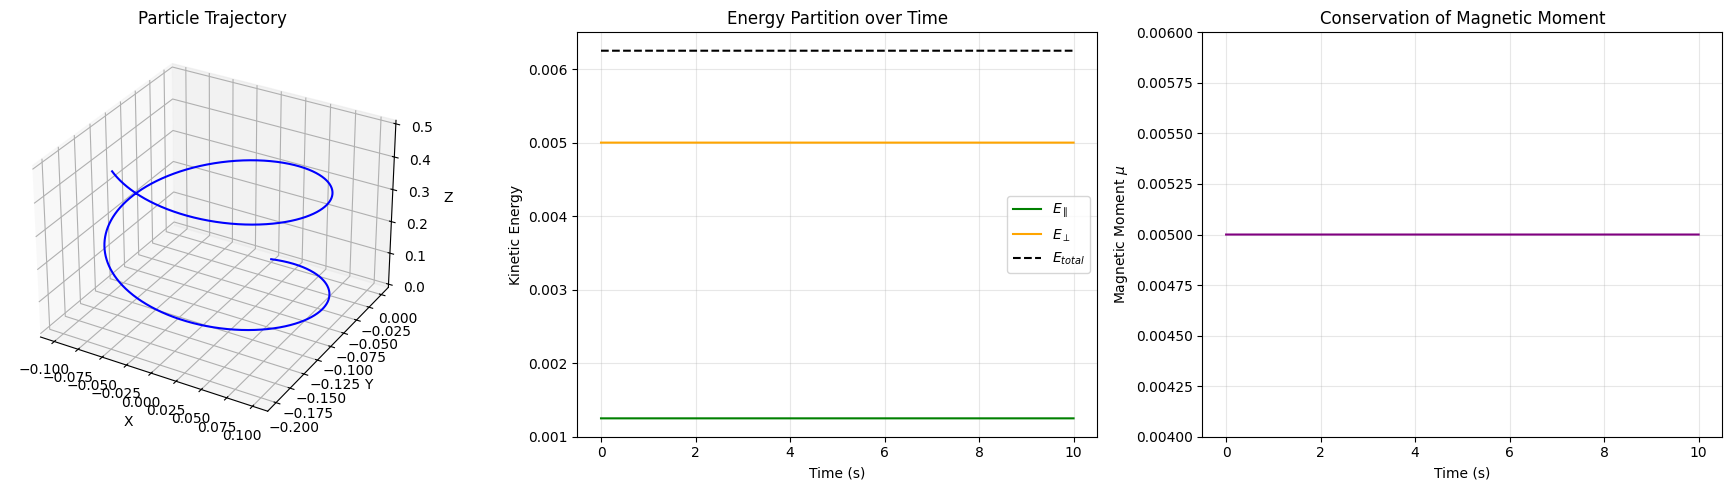

In [10]:

# Initialize simulation
sim_uniform = SimulationSetup(
    charge=q, 
    mass=m, 
    initial_pos=initial_pos, 
    initial_vel=initial_vel, 
    b_field=uniform_b_field,  
    dt=dt, 
    num_steps=num_steps
)

sim_uniform.run()
sim_uniform.plot_results()

Here, we see the result we were expecting: the particle spirals around the field lines. Also, the energy and magnetic moment are all conserved without any problems. These lasts due to the election of the Boris Integrator, which eases the conservation of these quantities. 

## Gradient drift

We're basically asked to model a weird magnetic field 

$$
    \vec B = (0.001x, 0.0, 1.0)T
$$

but, in this case, I'll model a more extreme case as it is more interesting to see it

$$
    \vec B = (0.05x, 0.0, 1.0)T
$$

with initial position $x = 5.0$ so the $\hat x$ drift is higher. Also, we'll use an initial velocity $\vec v_0 = (0.0, 0.1, 0.5)$ so our particle can easily feel the drifting component of the magnetic field. 

In [41]:
# Set Physical Parameters
q = 1.0
m = 1.0
initial_pos = [5.0, 0.0, 0.0]  # Start at the origin
initial_vel = [0.05, 0.05, 0.05]  # Moving mainly in x, slight drift in z

# Gradient magnetic field
gradient_b_field = lambda pos: np.array([0.05*pos[0], 0.0, 1.0]) 

# Simulation parameters
dt = 1.0e-2
num_steps = int(1e3)

Starting simulation...
Simulation complete.


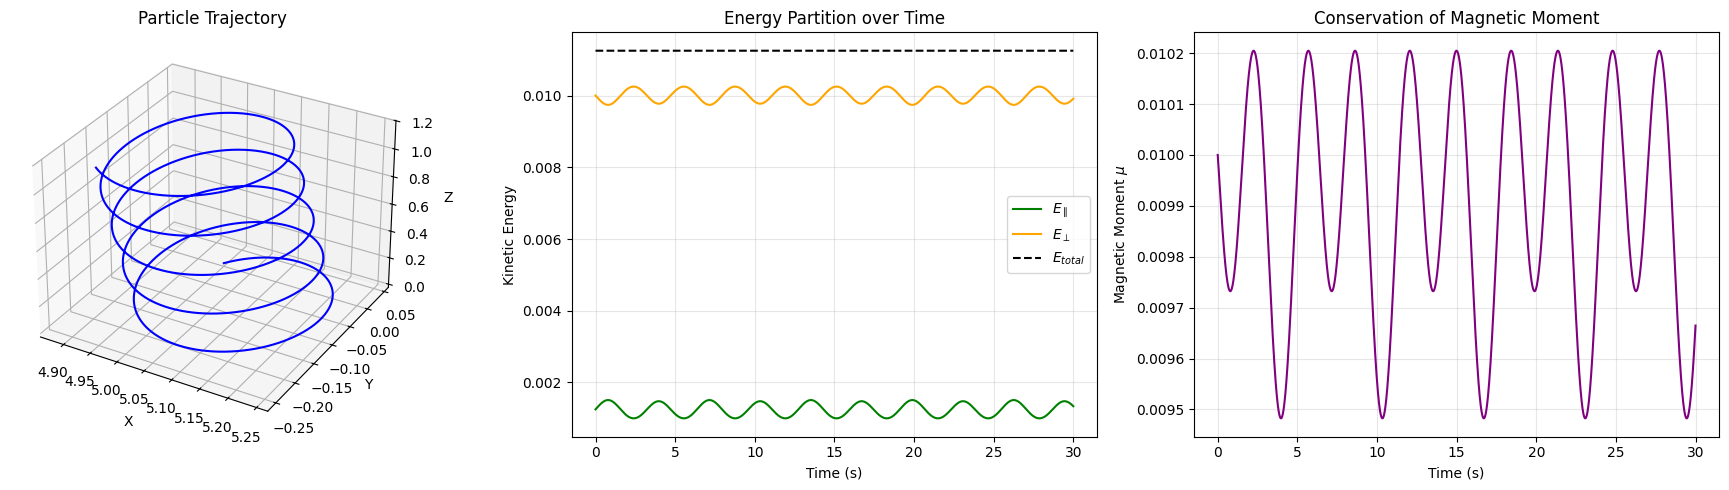

In [46]:
# Initialize simulation
sim_uniform = SimulationSetup(
    charge=q, 
    mass=m, 
    initial_pos=initial_pos, 
    initial_vel=initial_vel, 
    b_field=gradient_b_field,  
    dt=dt, 
    num_steps=num_steps,
    _keep_mu = 0.0,
)

sim_uniform.run()
sim_uniform.plot_results()

Here, we now see that the particle still spirals around, but moves along the $x$ axis at the same time. The energy is also conserved with no problem, but now, there's a huge problem: the magnetic moment IS NOT CONSERVED. This is due to this field NOT BEING PHYSICAL, so it breaks physical rules, as mentioned above. If we calculate this field's divergence, we get that $\nabla \cdot \vec B = 0.05 \ne 0$, so we cannot expect this field to lead to physical results. 


By the other hand, if we model a null-divergence drift field, such as

$$
    \vec B = (y, 0.0, 1.0)T
$$

we get

Starting simulation...
Simulation complete.


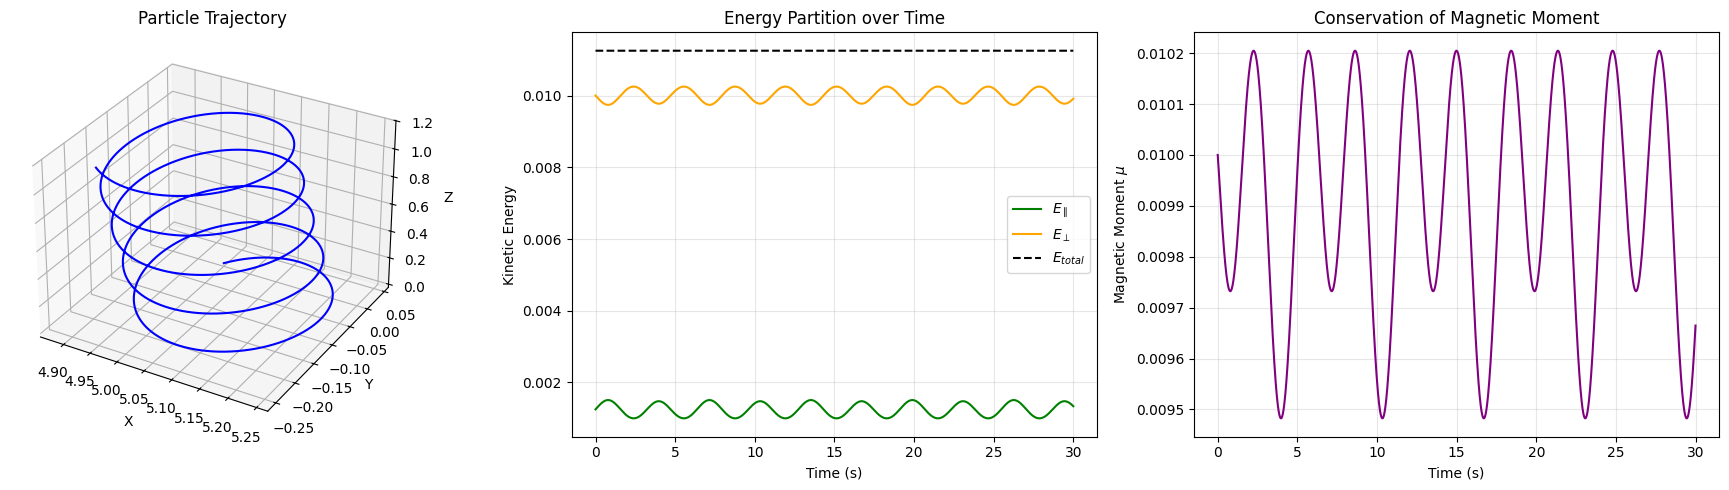

In [50]:
# Set Physical Parameters
q = 1.0
m = 1.0
initial_pos = [5.0, 0.0, 0.0]  # Start at the origin
initial_vel = [0.1, 0.1, 0.05]  # Moving mainly in x, slight drift in z

# Gradient magnetic field
gradient_b_field = lambda pos: np.array([1.0*pos[1], 0.0, 1.0]) 

# Simulation parameters
dt = 1.0e-2
num_steps = int(3e3)


# Initialize simulation
sim_uniform = SimulationSetup(
    charge=q, 
    mass=m, 
    initial_pos=initial_pos, 
    initial_vel=initial_vel, 
    b_field=gradient_b_field,  
    dt=dt, 
    num_steps=num_steps,
    _keep_mu = 0.0,
)

sim_uniform.run()
sim_uniform.plot_results()

That our magnetic moment OSCILLATES around a given value. Now, this is still certainly unexpected, but can also be explained.

This is due to our particle's spiral move. As it moves around, it feels a different field and thus it's magnetic moment will change as it oscillates around. To fix this, we'll first have to remmember that the conservation of $\mu$ only works for the _guiding center_ of the modion, which is the path the particles spirals around. With this in mind, we'll compute $\mu$ with respect to our guiding center.

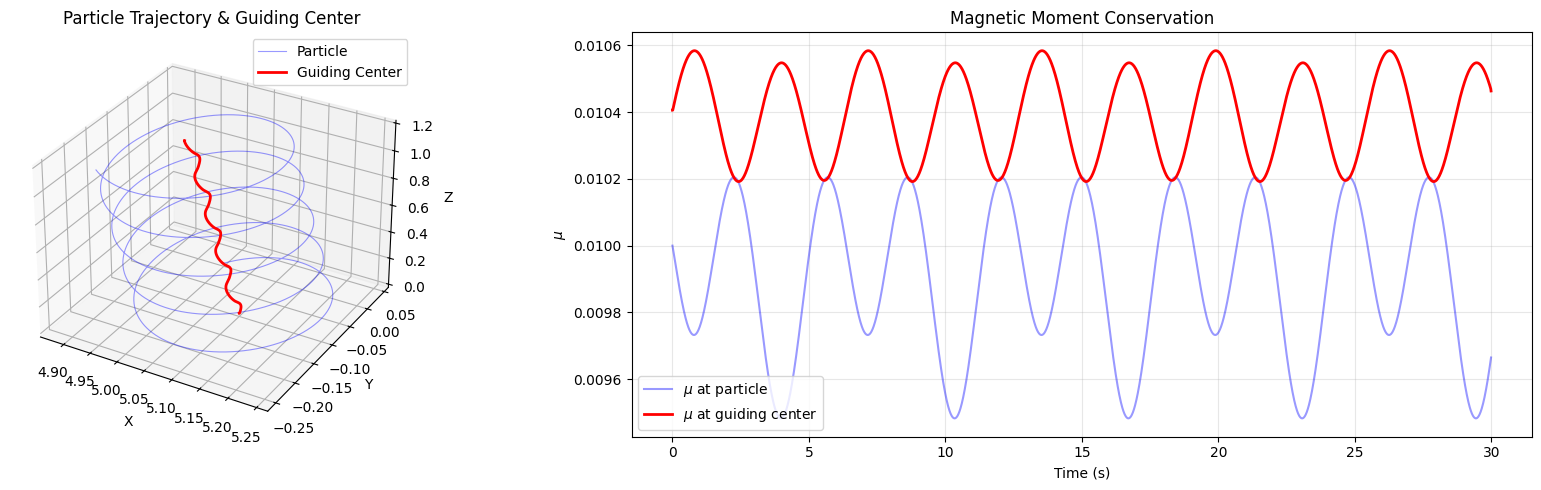

In [51]:
sim_uniform.plot_guiding_center()

We see now that the magnetic moment at the guiding center is by far way more conserved, but still not perfectly conserved. This is expected at this point, and can mostly be explained thanks to this guiding center's magnetic moment's conservation law applying only for uniform fields, and it is only approximately tre for non-uniform fields.

## Dipole field

Here, we'll model the particle in the Earth's magnetic field.

In [73]:
# Set Physical Parameters
q = 1.0
m = 1.0
initial_pos = [3.0, 0.0, 0.0]  # Start at L-shell
initial_vel = [0.01, 0.01, 0.01]  # Moving in x and z in such way that vx^2 + vz^2 = 14 so that K=7

# Define Earth's dipole field
def earth_dipole_field(pos):

    x, y, z = pos
    
    # Calculate radial distance r
    r = np.sqrt(x**2 + y**2 + z**2)
    
    # of we're on the center of Earth (which should not happen a priori), just make it 0
    if r < 1e-10:
        return np.array([0.0, 0.0, 0.0])
        
    # The combined constant
    C = 10.668
    
    # The prefactor
    prefactor = -C / (r**5)
    
    # Calculate the B field components
    Bx = prefactor * (3 * x * z)
    By = prefactor * (3 * y * z)
    Bz = prefactor * (2 * z**2 - x**2 - y**2)
    
    return np.array([Bx, By, Bz])

# Simulation Parameters 
dt = 0.01
num_steps = int(5e5)

Starting simulation...
Simulation complete.


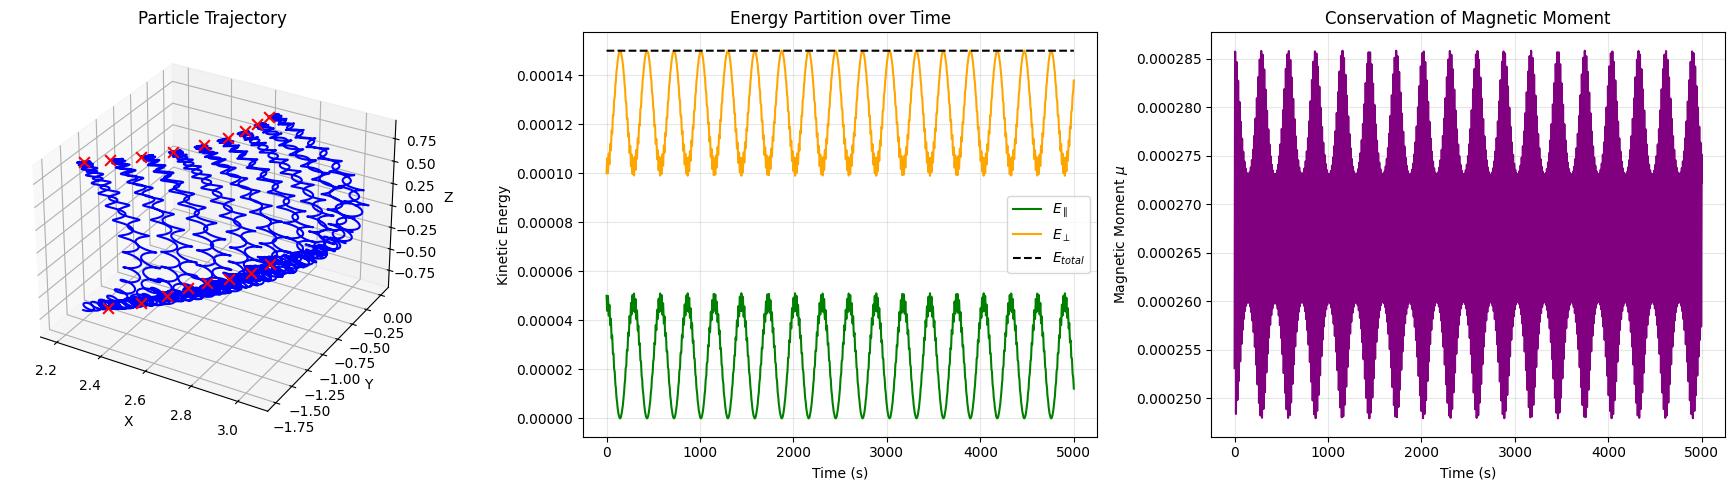

In [74]:
# Initialize simulation
sim_uniform = SimulationSetup(
    charge=q, 
    mass=m, 
    initial_pos=initial_pos, 
    initial_vel=initial_vel, 
    b_field=earth_dipole_field,  
    dt=dt, 
    num_steps=num_steps,
    _keep_mu = 0.0,
    # plot_lim = 3.0
)

sim_uniform.run()
sim_uniform.plot_results()

Here, we see the spected behaviour: the particle spirals around the field lines and ricochets at the mirror points, as predicted in the study material. Here, we can also see that our bisection method worked just nice in order to find these mirror points. The energy seems perfectly conserved aswell, and we see that the magnetic moment, as happened before, oscillates in a more complex way as we're dealing with a way more complex behaviour now. We're left to check how this changes when using the guiding center.

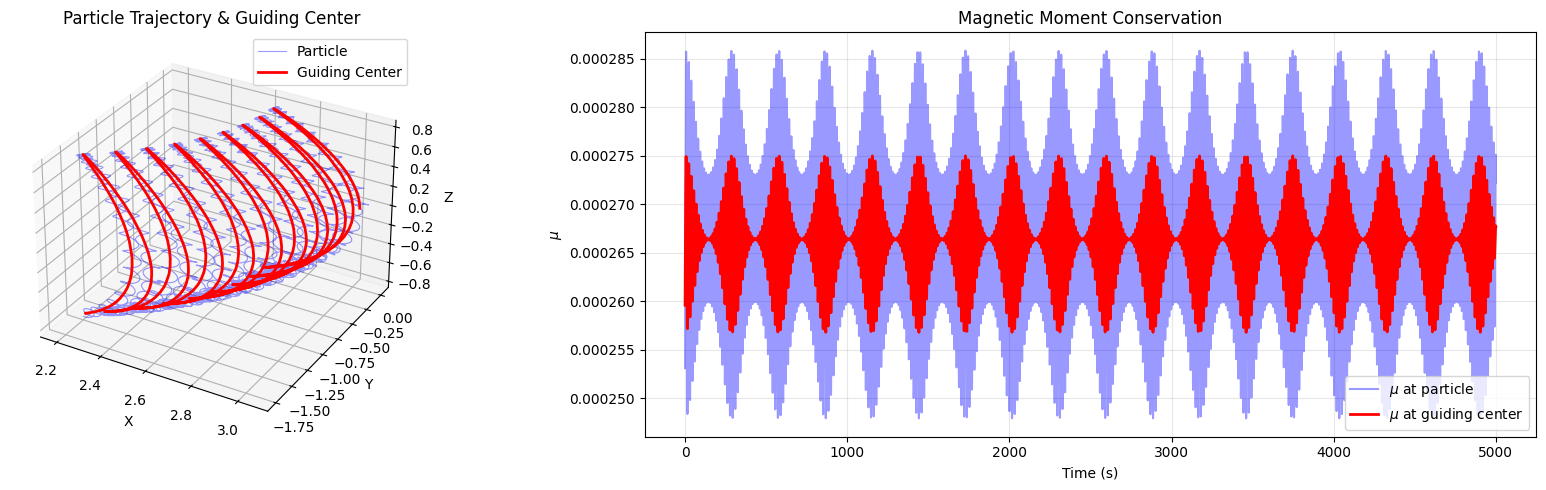

In [75]:
sim_uniform.plot_guiding_center()

Now, in this case, the guiding center approximation barely reduced this oscillation, but did not completely get rid of it. Appart from the considerations given priorly, this also has another explanation: this adiabatic magnetic moment approximation only works when the Lamour radius $r_L$ is too small (or at least, very small compared to $B / \nabla B$). In this case, something we can do is either use stronger fields (getting the particle even closer) or using a slower velocity, as it will decrease $r_L$

Starting simulation...
Simulation complete.


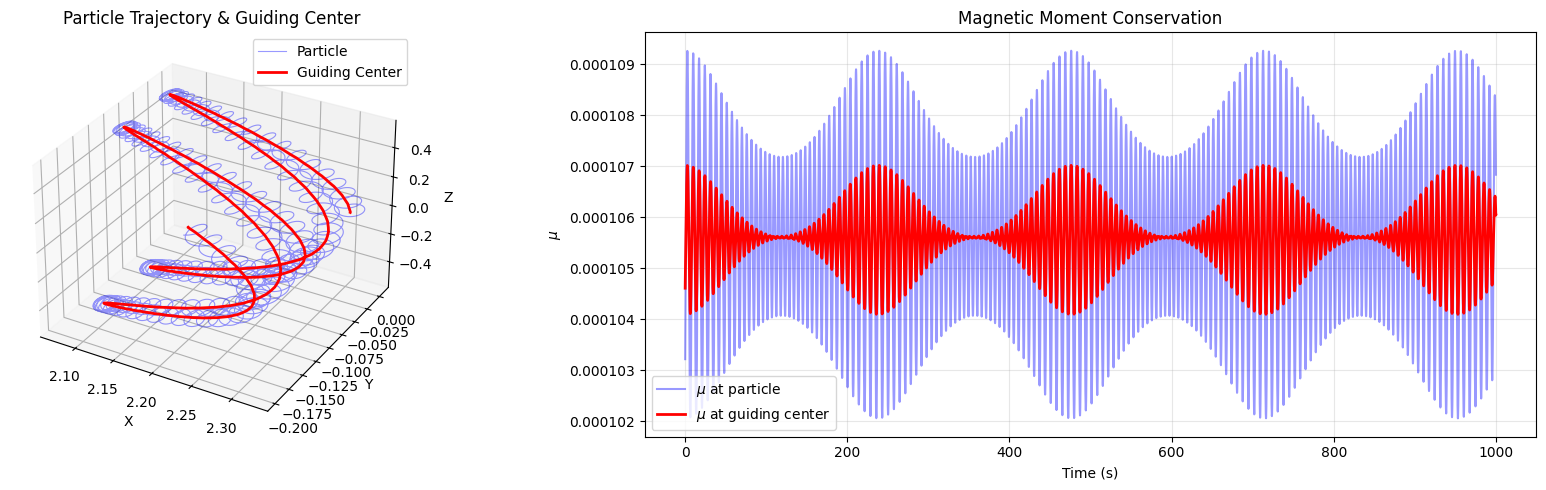

In [91]:
initial_pos = [2.3, 0.0, 0.0]
initial_vel = [0.01, 0.009, 0.008]  


# Initialize simulation
sim_uniform = SimulationSetup(
    charge=q, 
    mass=m, 
    initial_pos=initial_pos, 
    initial_vel=initial_vel, 
    b_field=earth_dipole_field,  
    dt=dt, 
    num_steps=int(1e5),
    _keep_mu = 0.0,
    # plot_lim = 3.0
)

sim_uniform.run()
sim_uniform.plot_guiding_center()

Now, having reduced already a little this $r_L / B$ factor, we can see that the magnetic moment, even if it still osccilates, it keeps it's mean constant, and the oscillation amplitud is smaller than both the real magnetic moment calculation and the GC calculation we did previously.

Starting simulation...
Simulation complete.


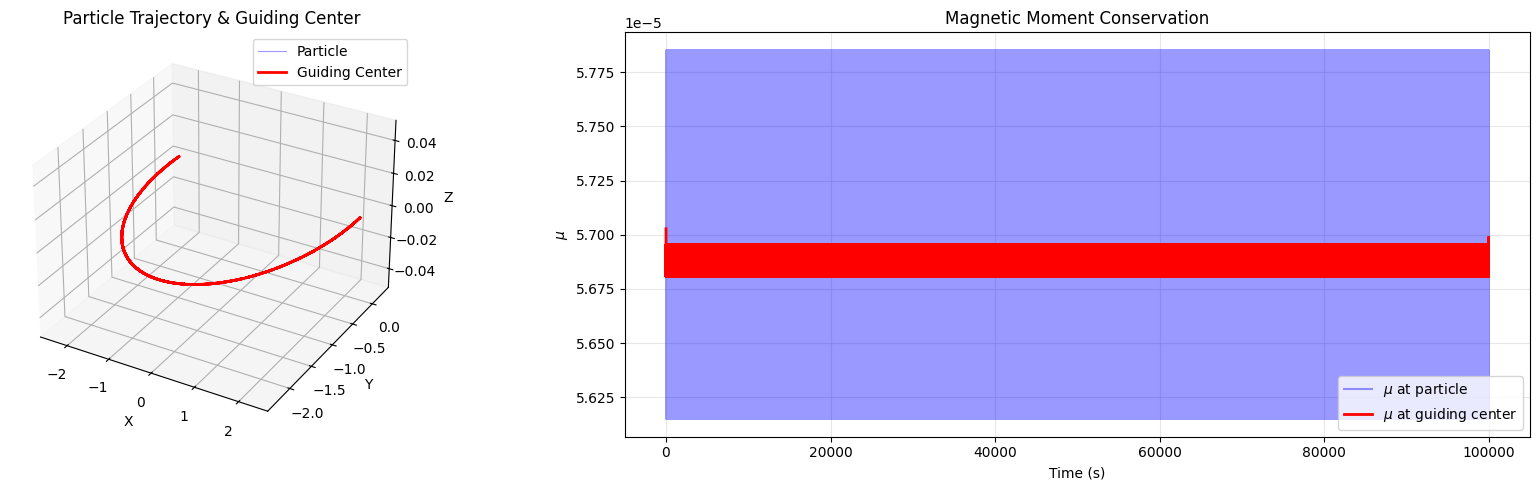

In [94]:
initial_pos = [2.3, 0.0, 0.0]
initial_vel = [0.01, 0.0, 0.0]  


# Initialize simulation
sim_uniform = SimulationSetup(
    charge=q, 
    mass=m, 
    initial_pos=initial_pos, 
    initial_vel=initial_vel, 
    b_field=earth_dipole_field,  
    dt=1.0e-1, 
    num_steps=int(1e6),
    _keep_mu = 0.0,
    # plot_lim = 3.0
)

sim_uniform.run()
sim_uniform.plot_guiding_center()

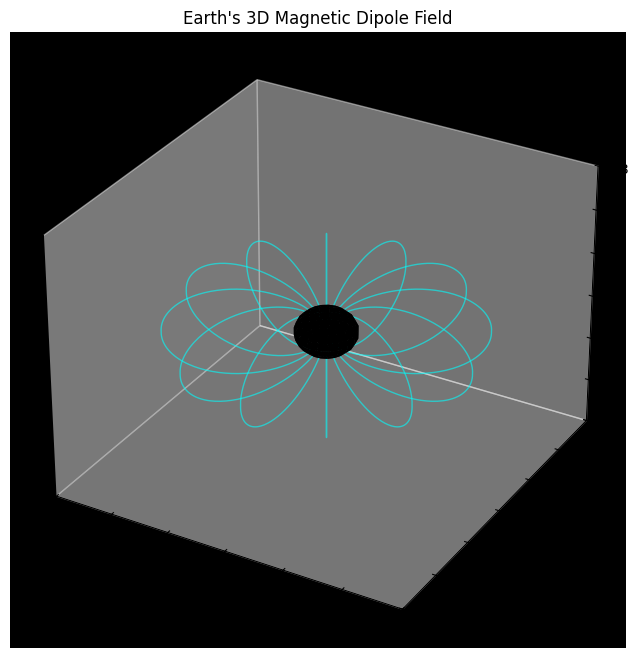

In [15]:
def trace_3d_field_lines(ax, b_field_func, seed_points, step_size=0.05, num_steps=500, color='gray', alpha=0.5):
    """
    Traces and plots 3D magnetic field lines starting from a list of seed points.
    It integrates both forwards and backwards along the B-field vector.
    """
    def integrate_line(start_pos, direction):
        line = [start_pos]
        pos = np.array(start_pos, dtype=float)
        
        for _ in range(num_steps):
            B = b_field_func(pos)
            B_mag = np.linalg.norm(B)
            
            # Stop if the field is zero, or if we get too close to the singularity at the origin
            r = np.linalg.norm(pos)
            if B_mag < 1e-14 or r < 0.2: 
                break
                
            # Move a tiny step exactly parallel (or anti-parallel) to the B-field
            pos = pos + direction * step_size * (B / B_mag)
            line.append(pos.copy())
            
        return np.array(line)

    # Plot lines for every seed point
    for seed in seed_points:
        # Trace forward (+B direction) and backward (-B direction)
        line_fwd = integrate_line(seed, direction=1)
        line_bwd = integrate_line(seed, direction=-1)
        
        # Combine them into a single line array
        full_line = np.vstack((line_bwd[::-1], line_fwd[1:]))
        
        # Plot on the provided 3D axis
        ax.plot(full_line[:, 0], full_line[:, 1], full_line[:, 2], color=color, alpha=alpha, linewidth=1)


# Setup Figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Create Seed Points (A ring around the equator at radius = 2.5)
radius = 2.5
seed_points = []
num_lines = 12
for angle in np.linspace(0, 2*np.pi, num_lines, endpoint=False):
    seed_x = radius * np.cos(angle)
    seed_y = radius * np.sin(angle)
    seed_z = 0.0 # Equator
    seed_points.append([seed_x, seed_y, seed_z])

# Trace the lines!
trace_3d_field_lines(ax, earth_dipole_field, seed_points, color='cyan', alpha=0.6)

# Draw a black sphere in the middle to represent Earth
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
ax.plot_surface(0.5*np.cos(u)*np.sin(v), 0.5*np.sin(u)*np.sin(v), 0.5*np.cos(v), color='k')

# Formatting
ax.set_xlim([-3, 3]); ax.set_ylim([-3, 3]); ax.set_zlim([-3, 3])
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title("Earth's 3D Magnetic Dipole Field")
ax.set_facecolor('black') # Looks cool in space!
ax.grid(False)
plt.show()